In [2]:
# CELL 1 - Imports
import os, random, cv2, numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f"TF: {tf.__version__}")
print(f"GPU: {tf.config.list_physical_devices('GPU')}")

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [51]:
# CELL 2 - Load CEDAR Verification Dataset

import os
from sklearn.preprocessing import LabelEncoder

ORG_DIR = "/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org"
FORG_DIR = "/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_forg"

image_paths = []
labels = []

# Genuine = 1
for fname in os.listdir(ORG_DIR):

    if fname.endswith(".png"):

        image_paths.append(
            os.path.join(ORG_DIR, fname)
        )

        labels.append(1)

# Forged = 0
for fname in os.listdir(FORG_DIR):

    if fname.endswith(".png"):

        image_paths.append(
            os.path.join(FORG_DIR, fname)
        )

        labels.append(0)

print("Total Images :", len(image_paths))
print("Genuine      :", sum(labels))
print("Forged       :", len(labels)-sum(labels))

Total Images : 2640
Genuine      : 1320
Forged       : 1320


In [52]:
# CELL 3 - Train / Validation / Test Split

from sklearn.model_selection import train_test_split
import numpy as np
import random

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.20,
    random_state=SEED,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

print("="*50)
print("DATASET SPLIT")
print("="*50)

print("Train :", len(X_train))
print("Val   :", len(X_val))
print("Test  :", len(X_test))

print("\nTrain Genuine :", sum(y_train))
print("Train Forged  :", len(y_train)-sum(y_train))

print("\nVal Genuine   :", sum(y_val))
print("Val Forged    :", len(y_val)-sum(y_val))

print("\nTest Genuine  :", sum(y_test))
print("Test Forged   :", len(y_test)-sum(y_test))

DATASET SPLIT
Train : 2112
Val   : 264
Test  : 264

Train Genuine : 1056
Train Forged  : 1056

Val Genuine   : 132
Val Forged    : 132

Test Genuine  : 132
Test Forged   : 132


In [53]:
# CELL 4 - tf.data Pipeline

IMG_SIZE = 224
BATCH_SIZE = 32
AUTO = tf.data.AUTOTUNE

def read_image(path, label):

    img = tf.io.read_file(path)
    img = tf.image.decode_png(img, channels=3)

    img = tf.image.resize(
        img,
        [IMG_SIZE, IMG_SIZE]
    )

    img = tf.cast(img, tf.float32) / 255.0

    # InceptionV3 preprocessing
    img = (img - 0.5) * 2.0

    return img, tf.cast(label, tf.float32)


def augment(img, label):

    img = tf.image.random_brightness(
        img,
        max_delta=0.15
    )

    img = tf.image.random_contrast(
        img,
        lower=0.85,
        upper=1.15
    )

    crop_size = tf.random.uniform(
        [],
        minval=190,
        maxval=224,
        dtype=tf.int32
    )

    img = tf.image.random_crop(
        img,
        [crop_size, crop_size, 3]
    )

    img = tf.image.resize(
        img,
        [224,224]
    )

    dx = tf.random.uniform(
        [],
        minval=-15,
        maxval=15,
        dtype=tf.int32
    )

    dy = tf.random.uniform(
        [],
        minval=-15,
        maxval=15,
        dtype=tf.int32
    )

    img = tf.roll(img, dx, axis=1)
    img = tf.roll(img, dy, axis=0)

    img = tf.clip_by_value(
        img,
        -1.0,
        1.0
    )

    return img, label


def make_dataset(paths,
                 labels,
                 training=False):

    ds = tf.data.Dataset.from_tensor_slices(
        (
            tf.constant(paths),
            tf.constant(labels, dtype=tf.float32)
        )
    )

    if training:
        ds = ds.shuffle(
            len(paths),
            seed=42
        )

    ds = ds.map(
        read_image,
        num_parallel_calls=AUTO
    )

    if training:
        ds = ds.map(
            augment,
            num_parallel_calls=AUTO
        )

    ds = ds.batch(BATCH_SIZE)

    ds = ds.prefetch(AUTO)

    return ds


train_ds = make_dataset(
    X_train,
    y_train,
    training=True
)

val_ds = make_dataset(
    X_val,
    y_val,
    training=False
)

test_ds = make_dataset(
    X_test,
    y_test,
    training=False
)

for bx, by in train_ds.take(1):

    print("Images :", bx.shape)
    print("Labels :", by.shape)

    print(
        "Range:",
        bx.numpy().min(),
        bx.numpy().max()
    )

    print(
        "Label sample:",
        by[:10].numpy()
    )

print("\n✓ Verification pipeline ready")

Images : (32, 224, 224, 3)
Labels : (32,)
Range: -0.69202673 1.0
Label sample: [1. 0. 1. 0. 1. 1. 0. 0. 0. 1.]

✓ Verification pipeline ready


In [83]:
# CELL 5 - Type2Fuzzy Layer

class Type2Fuzzy(layers.Layer):

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def build(self, input_shape):

        c = int(input_shape[-1])

        self.a = self.add_weight(
            name="a",
            shape=(c,),
            initializer=tf.keras.initializers.Constant(0.5),
            trainable=True
        )

        self.P = self.add_weight(
            name="P",
            shape=(c,),
            initializer="ones",
            trainable=True
        )

        self.N = self.add_weight(
            name="N",
            shape=(c,),
            initializer="ones",
            trainable=True
        )

        super().build(input_shape)

    def _k(self, s, a):

        a = tf.clip_by_value(a, 0.02, 0.98)

        eps = 1e-5

        d1 = a + s - a*s
        d2 = -1.0 + a*s

        d1 = tf.where(
            tf.abs(d1) < eps,
            tf.ones_like(d1)*eps,
            d1
        )

        d2 = tf.where(
            tf.abs(d2) < eps,
            -tf.ones_like(d2)*eps,
            d2
        )

        return 0.5 * (
            1.0/d1 +
            (-1.0+a)/d2
        )

    def call(self, x):

        sh = [1,1,1,-1] if len(x.shape)==4 else [1,-1]

        a = tf.clip_by_value(
            tf.reshape(self.a, sh),
            0.02,
            0.98
        )

        P = tf.reshape(self.P, sh)
        N = tf.reshape(self.N, sh)

        return tf.where(
            x > 0,
            P*x*self._k(x,a),
            N*x*self._k(-x,a)
        )

    def get_config(self):
        return super().get_config()


print("✓ Type2Fuzzy Layer Ready")

✓ Type2Fuzzy Layer Ready


In [54]:
# CELL 6 - DT2F-TLNet Verification

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3
import numpy as np

def build_dt2f_tlnet_verification():

    inp = keras.Input(shape=(224,224,3))

    # =====================================================
    # MODEL II - InceptionV3
    # =====================================================

    inception = InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    inception.trainable = False

    x2 = inception(inp)

    x2 = layers.GlobalAveragePooling2D()(x2)

    x2 = layers.BatchNormalization()(x2)

    F2 = layers.Dense(
        512,
        activation=None
    )(x2)

    # =====================================================
    # MODEL I - Type2Fuzzy CNN
    # =====================================================

    x1 = layers.Conv2D(
        16,
        3,
        padding="same",
        use_bias=False
    )(inp)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        32,
        3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        64,
        3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        128,
        3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        256,
        3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)

    F1 = layers.GlobalAveragePooling2D()(x1)

    # =====================================================
    # Feature Fusion
    # =====================================================

    x = layers.Concatenate()([F1, F2])

    x = layers.Dense(
        200,
        use_bias=False
    )(x)

    x = layers.BatchNormalization()(x)

    x = Type2Fuzzy()(x)

    x = layers.Dropout(0.5)(x)

    out = layers.Dense(
        1,
        activation="sigmoid"
    )(x)

    return keras.Model(
        inp,
        out,
        name="DT2F_TLNet_Verification"
    )

model = build_dt2f_tlnet_verification()

model.compile(
    optimizer=keras.optimizers.RMSprop(
        learning_rate=5e-4
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

print("="*60)
print("DT2F-TLNet Verification")
print("="*60)

print(
    "Total Params:",
    f"{model.count_params():,}"
)

print(
    "Trainable Params:",
    f"{sum(np.prod(v.shape) for v in model.trainable_variables):,}"
)

DT2F-TLNet Verification
Total Params: 23,410,849
Trainable Params: 1,602,577


In [80]:
# DT2F-TLNet Architecture

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3

def build_dt2f_tlnet(num_classes):

    inp = keras.Input(shape=(224,224,3))

    # =====================================================
    # Model II : InceptionV3 Branch
    # =====================================================

    inception = InceptionV3(
        weights="imagenet",
        include_top=False,
        input_shape=(224,224,3)
    )

    inception.trainable = False

    x2 = inception(inp)

    x2 = layers.GlobalAveragePooling2D()(x2)

    x2 = layers.BatchNormalization()(x2)

    F2 = layers.Dense(
        512,
        activation=None
    )(x2)

    # =====================================================
    # Model I : Type-2 Fuzzy CNN Branch
    # =====================================================

    x1 = layers.Conv2D(
        16, 3,
        padding="same",
        use_bias=False
    )(inp)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        32, 3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        64, 3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        128, 3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)
    x1 = layers.MaxPooling2D()(x1)

    x1 = layers.Conv2D(
        256, 3,
        padding="same",
        use_bias=False
    )(x1)

    x1 = layers.BatchNormalization()(x1)
    x1 = Type2Fuzzy()(x1)

    F1 = layers.GlobalAveragePooling2D()(x1)

    # =====================================================
    # Feature Fusion
    # =====================================================

    fusion = layers.Concatenate()([F1, F2])

    x = layers.Dense(
        200,
        use_bias=False
    )(fusion)

    x = layers.BatchNormalization()(x)

    x = Type2Fuzzy()(x)

    x = layers.Dropout(0.5)(x)

    # =====================================================
    # Output Layer
    # =====================================================

    out = layers.Dense(
        num_classes,
        activation="softmax"
    )(x)

    model = keras.Model(
        inputs=inp,
        outputs=out,
        name="DT2F_TLNet"
    )

    return model

In [82]:
# Build Model
NUM_CLASSES = 2   # For Genuine vs Forged

model = build_dt2f_tlnet(NUM_CLASSES)

# Compile
model.compile(
    optimizer=keras.optimizers.RMSprop(
        learning_rate=1e-3
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

# Print Information
print("="*60)
print("DT2F-TLNet")
print("="*60)

print(
    f"Total Params: "
    f"{model.count_params():,}"
)

print(
    f"Trainable Params: "
    f"{sum(np.prod(v.shape) for v in model.trainable_variables):,}"
)

print(
    f"Non-Trainable Params: "
    f"{sum(np.prod(v.shape) for v in model.non_trainable_variables):,}"
)

# Full Summary
model.summary()

DT2F-TLNet
Total Params: 23,411,050
Trainable Params: 1,602,778
Non-Trainable Params: 21,808,274


Model: "DT2F_TLNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_774 (Conv2D) │ (None, 224, 224,  │        432 │ input_layer_14[0… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 224, 224,  │         64 │ conv2d_774[0][0]  │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type2_fuzzy_26      │ (None, 224, 224,  │         48 │ batch_normalizat… │
│ (Type2Fuzzy)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_48    │ (None, 112, 112,  │          0 │ type2_fuzzy_26[0… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_775 (Conv2D) │ (None, 112, 112,  │      4,608 │ max_pooling2d_48… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 112, 112,  │        128 │ conv2d_775[0][0]  │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type2_fuzzy_27      │ (None, 112, 112,  │         96 │ batch_normalizat… │
│ (Type2Fuzzy)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_49    │ (None, 56, 56,    │          0 │ type2_fuzzy_27[0… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_776 (Conv2D) │ (None, 56, 56,    │     18,432 │ max_pooling2d_49… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 56, 56,    │        256 │ conv2d_776[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type2_fuzzy_28      │ (None, 56, 56,    │        192 │ batch_normalizat… │
│ (Type2Fuzzy)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_50    │ (None, 28, 28,    │          0 │ type2_fuzzy_28[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_777 (Conv2D) │ (None, 28, 28,    │     73,728 │ max_pooling2d_50… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 28, 28,    │        512 │ conv2d_777[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ type2_fuzzy_29      │ (None, 28, 28,    │        384 │ batch_normalizat… │
│ (Type2Fuzzy)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_51    │ (None, 14, 14,    │          0 │ type2_fuzzy_29[0

 Total params: 23,411,050 (89.31 MB)

 Trainable params: 1,602,778 (6.11 MB)

 Non-trainable params: 21,808,272 (83.19 MB)

In [63]:
# CELL 7 - Phase 1 Training

EPOCHS_P1 = 15

callbacks_p1 = [

    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_verification_p1.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=6,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.LambdaCallback(
        on_epoch_end=lambda e, logs:
        print(
            f"Ep {e+1:02d} | "
            f"Train={logs['accuracy']*100:.2f}% | "
            f"Val={logs['val_accuracy']*100:.2f}% | "
            f"AUC={logs['val_auc']:.4f} | "
            f"Loss={logs['loss']:.4f}"
        )
    )
]

print("="*60)
print("PHASE 1 - VERIFICATION")
print("="*60)

history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P1,
    callbacks=callbacks_p1,
    verbose=0
)

best_acc = max(history1.history["val_accuracy"]) * 100
best_auc = max(history1.history["val_auc"])

print("\n" + "="*60)
print(f"Best Val Accuracy : {best_acc:.2f}%")
print(f"Best Val AUC      : {best_auc:.4f}")
print("="*60)

PHASE 1 - VERIFICATION

Epoch 1: val_accuracy improved from None to 0.78030, saving model to /kaggle/working/best_verification_p1.keras

Epoch 1: finished saving model to /kaggle/working/best_verification_p1.keras
Ep 01 | Train=80.07% | Val=78.03% | AUC=0.8513 | Loss=0.9293

Epoch 2: val_accuracy did not improve from 0.78030
Ep 02 | Train=79.83% | Val=75.00% | AUC=0.8332 | Loss=0.9507

Epoch 3: val_accuracy did not improve from 0.78030
Ep 03 | Train=80.82% | Val=76.14% | AUC=0.8243 | Loss=0.8557

Epoch 4: val_accuracy did not improve from 0.78030

Epoch 4: ReduceLROnPlateau reducing learning rate to 1.249999968422344e-06.
Ep 04 | Train=81.91% | Val=75.38% | AUC=0.8308 | Loss=0.8802

Epoch 5: val_accuracy did not improve from 0.78030
Ep 05 | Train=79.55% | Val=76.14% | AUC=0.8334 | Loss=0.9340

Epoch 6: val_accuracy did not improve from 0.78030
Ep 06 | Train=80.54% | Val=75.76% | AUC=0.8477 | Loss=0.8841

Epoch 7: val_accuracy did not improve from 0.78030

Epoch 7: ReduceLROnPlateau red

In [65]:
# TEST EVALUATION

test_loss, test_acc, test_auc = model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "="*60)
print(f"TEST ACCURACY : {test_acc*100:.2f}%")
print(f"TEST AUC      : {test_auc:.4f}")
print(f"TEST LOSS     : {test_loss:.4f}")
print("="*60)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 67ms/step - accuracy: 0.8258 - auc: 0.8704 - loss: 0.6783

TEST ACCURACY : 82.58%
TEST AUC      : 0.8704
TEST LOSS     : 0.6783


In [66]:
# CELL 8 - Unfreeze top 20 Inception layers

model.save("/kaggle/working/verification_phase1.keras")

inception = None

for layer in model.layers:
    if "inception_v3" in layer.name:
        inception = layer
        break

print("Found:", inception.name)

inception.trainable = True

# Freeze all except last 20 layers
for layer in inception.layers[:-20]:
    layer.trainable = False

for layer in inception.layers[-20:]:
    layer.trainable = True

model.compile(
    optimizer=keras.optimizers.RMSprop(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        keras.metrics.AUC(name="auc")
    ]
)

trainable_params = sum(
    np.prod(v.shape)
    for v in model.trainable_variables
)

print("Trainable Params:", f"{trainable_params:,}")

Found: inception_v3
Trainable Params: 3,537,937


In [67]:
# CELL 9 - Phase 2 Fine-Tuning

EPOCHS_P2 = 10

callbacks_p2 = [

    keras.callbacks.ModelCheckpoint(
        "/kaggle/working/best_verification_p2.keras",
        monitor="val_accuracy",
        save_best_only=True,
        mode="max",
        verbose=1
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-7,
        verbose=1
    ),

    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=4,
        restore_best_weights=True,
        verbose=1
    ),

    keras.callbacks.LambdaCallback(
        on_epoch_end=lambda e, logs:
        print(
            f"Ep {e+1:02d} | "
            f"Train={logs['accuracy']*100:.2f}% | "
            f"Val={logs['val_accuracy']*100:.2f}% | "
            f"AUC={logs['val_auc']:.4f} | "
            f"Loss={logs['loss']:.4f}"
        )
    )
]

print("="*60)
print("PHASE 2 - FINE TUNING")
print("="*60)

history2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_P2,
    callbacks=callbacks_p2,
    verbose=0
)

best_acc = max(history2.history["val_accuracy"]) * 100
best_auc = max(history2.history["val_auc"])

print("\n" + "="*60)
print(f"Best Phase 2 Accuracy : {best_acc:.2f}%")
print(f"Best Phase 2 AUC      : {best_auc:.4f}")
print("="*60)

PHASE 2 - FINE TUNING

Epoch 1: val_accuracy improved from None to 0.74242, saving model to /kaggle/working/best_verification_p2.keras

Epoch 1: finished saving model to /kaggle/working/best_verification_p2.keras
Ep 01 | Train=80.35% | Val=74.24% | AUC=0.8308 | Loss=0.9746

Epoch 2: val_accuracy improved from 0.74242 to 0.78788, saving model to /kaggle/working/best_verification_p2.keras

Epoch 2: finished saving model to /kaggle/working/best_verification_p2.keras
Ep 02 | Train=79.45% | Val=78.79% | AUC=0.8465 | Loss=0.9665

Epoch 3: val_accuracy did not improve from 0.78788
Ep 03 | Train=81.20% | Val=73.86% | AUC=0.8262 | Loss=0.8162

Epoch 4: val_accuracy did not improve from 0.78788

Epoch 4: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-06.
Ep 04 | Train=82.20% | Val=78.41% | AUC=0.8304 | Loss=0.8447

Epoch 5: val_accuracy improved from 0.78788 to 0.79167, saving model to /kaggle/working/best_verification_p2.keras

Epoch 5: finished saving model to /kaggle/working/b

In [68]:
# TEST EVALUATION

test_loss, test_acc, test_auc = model.evaluate(
    test_ds,
    verbose=1
)

print("\n" + "="*60)
print(f"TEST ACCURACY : {test_acc*100:.2f}%")
print(f"TEST AUC      : {test_auc:.4f}")
print(f"TEST LOSS     : {test_loss:.4f}")
print("="*60)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.8030 - auc: 0.8621 - loss: 0.8087

TEST ACCURACY : 80.30%
TEST AUC      : 0.8621
TEST LOSS     : 0.8087


In [69]:
print(history1.history.keys())
print(history2.history.keys())

dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss', 'learning_rate'])
dict_keys(['accuracy', 'auc', 'loss', 'val_accuracy', 'val_auc', 'val_loss', 'learning_rate'])


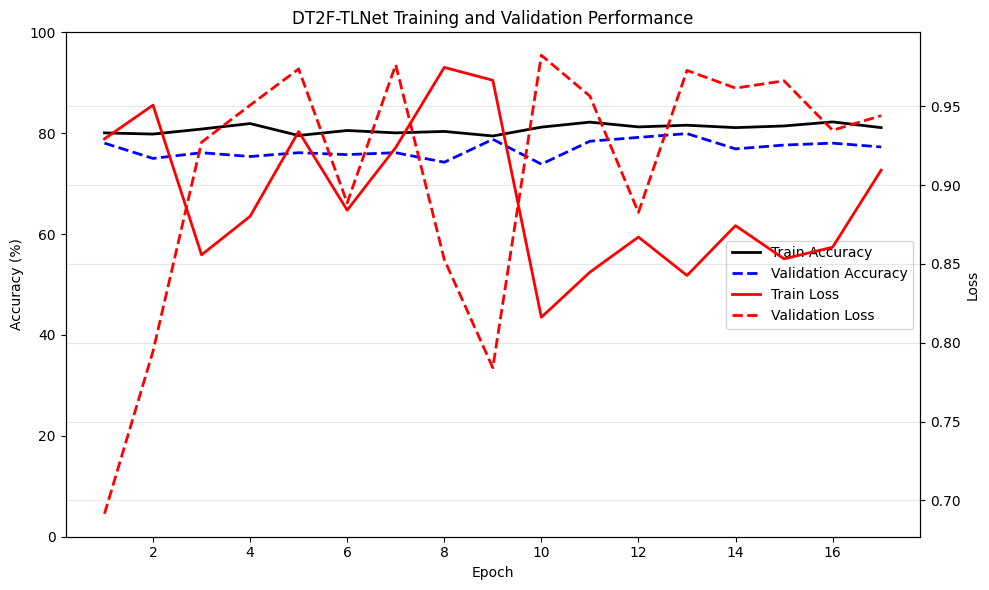

In [70]:
import matplotlib.pyplot as plt
import numpy as np

# Combine Phase1 + Phase2 histories
train_acc = history1.history["accuracy"] + history2.history["accuracy"]
val_acc   = history1.history["val_accuracy"] + history2.history["val_accuracy"]

train_loss = history1.history["loss"] + history2.history["loss"]
val_loss   = history1.history["val_loss"] + history2.history["val_loss"]

epochs = np.arange(1, len(train_acc)+1)

fig, ax1 = plt.subplots(figsize=(10,6))

# Accuracy
ax1.plot(
    epochs,
    np.array(train_acc)*100,
    'k-',
    linewidth=2,
    label='Train Accuracy'
)

ax1.plot(
    epochs,
    np.array(val_acc)*100,
    'b--',
    linewidth=2,
    label='Validation Accuracy'
)

ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy (%)")
ax1.set_ylim(0,100)

# Loss
ax2 = ax1.twinx()

ax2.plot(
    epochs,
    train_loss,
    'r-',
    linewidth=2,
    label='Train Loss'
)

ax2.plot(
    epochs,
    val_loss,
    'r--',
    linewidth=2,
    label='Validation Loss'
)

ax2.set_ylabel("Loss")

# Legend
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax1.legend(
    lines1 + lines2,
    labels1 + labels2,
    loc='center right'
)

plt.title("DT2F-TLNet Training and Validation Performance")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 960ms/step


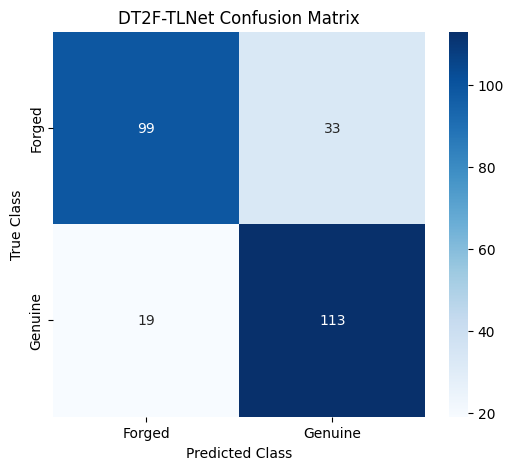

[[ 99  33]
 [ 19 113]]


In [71]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Predictions
y_prob = model.predict(test_ds)

y_pred = (y_prob > 0.5).astype(int).flatten()

# True labels
y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
).astype(int)

cm = confusion_matrix(
    y_true,
    y_pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Forged","Genuine"],
    yticklabels=["Forged","Genuine"]
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("DT2F-TLNet Confusion Matrix")

plt.show()

print(cm)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 64ms/step


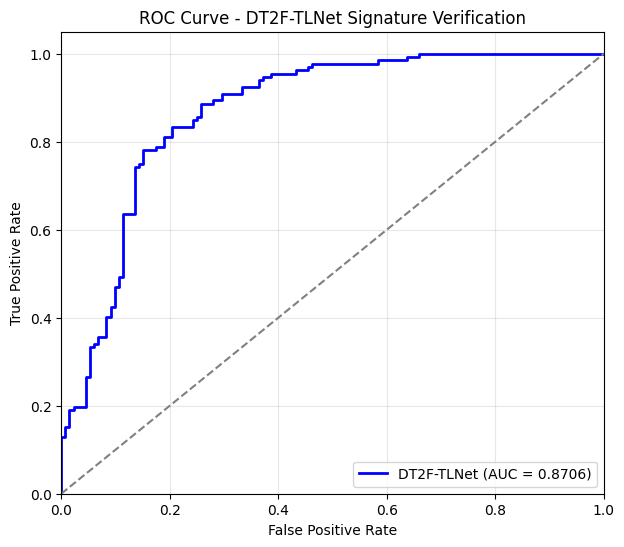

AUC = 0.8706


In [72]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt
import numpy as np

# Get probabilities
y_prob = model.predict(test_ds).ravel()

# Get true labels
y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
)

# ROC
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_prob
)

roc_auc = auc(
    fpr,
    tpr
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    color="blue",
    linewidth=2,
    label=f"DT2F-TLNet (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="gray"
)

plt.xlim([0,1])
plt.ylim([0,1.05])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve - DT2F-TLNet Signature Verification")

plt.legend(loc="lower right")

plt.grid(alpha=0.3)

plt.show()

print(f"AUC = {roc_auc:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 15s 947ms/step
Feature Shape: (264, 200)


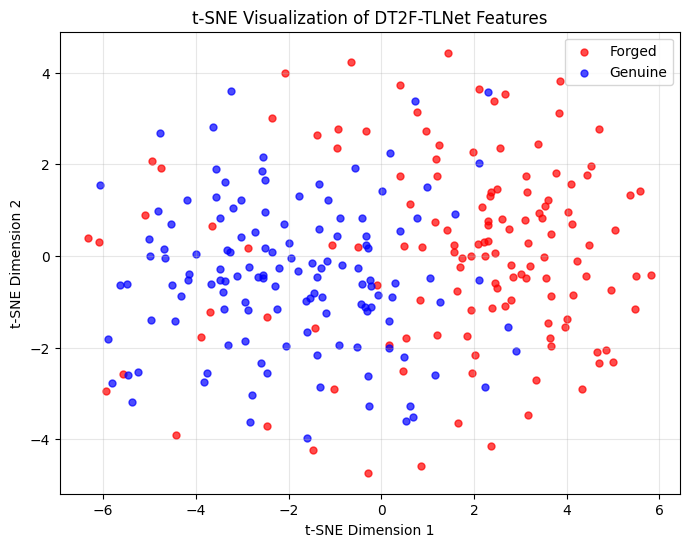

In [74]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from tensorflow import keras

# Feature extractor
feature_model = keras.Model(
    inputs=model.input,
    outputs=model.layers[-2].output
)

# Extract features
features = feature_model.predict(
    test_ds,
    verbose=1
)

# True labels
y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
).astype(int)

print("Feature Shape:", features.shape)

# t-SNE
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=42
)

tsne_features = tsne.fit_transform(features)

# Plot
plt.figure(figsize=(8,6))

for cls, color, name in [
    (0, "red", "Forged"),
    (1, "blue", "Genuine")
]:
    idx = y_true == cls

    plt.scatter(
        tsne_features[idx,0],
        tsne_features[idx,1],
        c=color,
        label=name,
        alpha=0.7,
        s=25
    )

plt.legend()
plt.title("t-SNE Visualization of DT2F-TLNet Features")
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.grid(alpha=0.3)

plt.show()

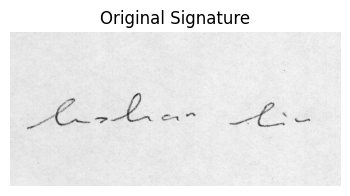

/kaggle/input/datasets/shreelakshmigp/cedardataset/signatures/full_org/original_52_13.png


In [75]:
import matplotlib.pyplot as plt
import cv2

sample_path = image_paths[0]

img = cv2.imread(sample_path, cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(8,2))
plt.imshow(img, cmap='gray')
plt.axis("off")
plt.title("Original Signature")
plt.show()

print(sample_path)

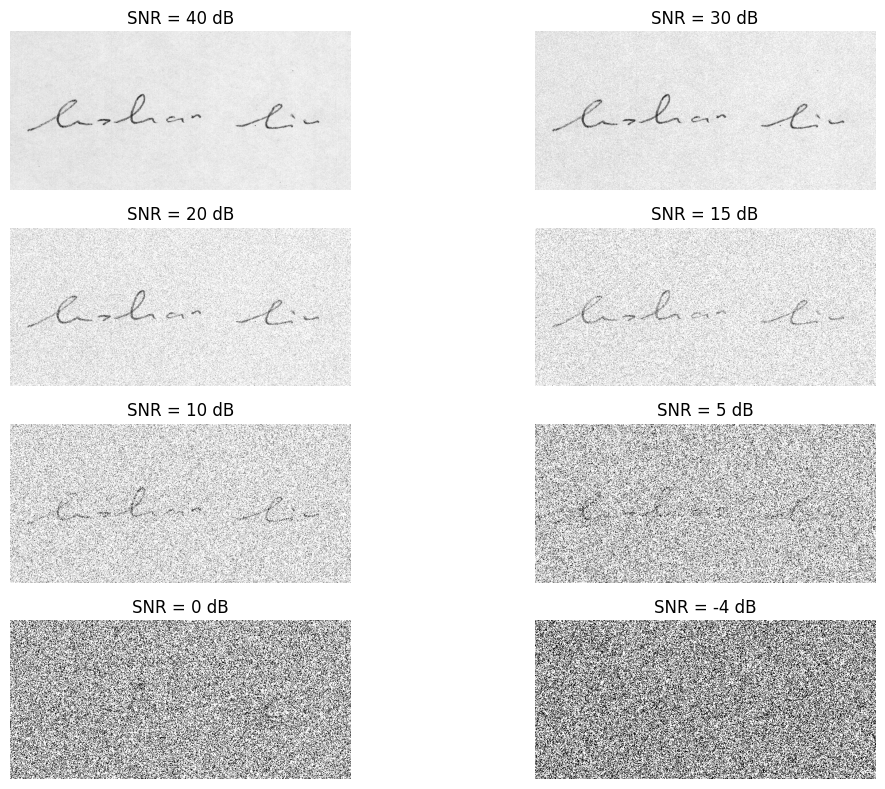

In [76]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def add_noise_snr(img, snr_db):

    img = img.astype(np.float32)

    signal_power = np.mean(img ** 2)

    snr_linear = 10 ** (snr_db / 10)

    noise_power = signal_power / snr_linear

    noise = np.random.normal(
        0,
        np.sqrt(noise_power),
        img.shape
    )

    noisy = img + noise

    noisy = np.clip(
        noisy,
        0,
        255
    )

    return noisy.astype(np.uint8)


snr_levels = [40, 30, 20, 15, 10, 5, 0, -4]

fig, axes = plt.subplots(
    4,
    2,
    figsize=(12,8)
)

for ax, snr in zip(axes.ravel(), snr_levels):

    noisy_img = add_noise_snr(img, snr)

    ax.imshow(
        noisy_img,
        cmap="gray"
    )

    ax.set_title(
        f"SNR = {snr} dB"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# probabilities
y_prob = model.predict(test_ds)

# predictions
y_pred = (y_prob > 0.5).astype(int).flatten()

# true labels
import numpy as np

y_true = np.concatenate(
    [y.numpy() for x, y in test_ds]
).astype(int)

print("="*60)
print("TEST METRICS")
print("="*60)

print(
    "Accuracy :",
    accuracy_score(y_true, y_pred)
)

print(
    "Precision:",
    precision_score(y_true, y_pred)
)

print(
    "Recall   :",
    recall_score(y_true, y_pred)
)

print(
    "F1 Score :",
    f1_score(y_true, y_pred)
)

print("\nClassification Report")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Forged",
            "Genuine"
        ]
    )
)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step
TEST METRICS
Accuracy : 0.803030303030303
Precision: 0.773972602739726
Recall   : 0.8560606060606061
F1 Score : 0.8129496402877698

Classification Report
              precision    recall  f1-score   support

      Forged       0.84      0.75      0.79       132
     Genuine       0.77      0.86      0.81       132

    accuracy                           0.80       264
   macro avg       0.81      0.80      0.80       264
weighted avg       0.81      0.80      0.80       264



In [79]:
print(model.evaluate(test_ds, verbose=0))

[0.8087226748466492, 0.8030303120613098, 0.8621155023574829]
